# 📡 LMS 自适应滤波量化策略

> 对微博博主 **「实战期货的程序员」L.M.S 战法** 的技术复刻尝试。

**⚠️ 诚实声明**：博主的 L.M.S 5.0 源码/规则未公开，我查不到。本 Notebook 按 **L.M.S = Least Mean Squares（最小均方自适应滤波，Widrow-Hoff 1960）** 这一经典信号处理算法复刻，**非其专有实现**。拿到确切规则可直接替换核心逻辑。

全中文、多图表，覆盖 **原理 → 滤波器演示 → 走窗预测 → 多空回测 → 参数分析**。

## 0️⃣ 环境与配置

In [1]:
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
os.environ.setdefault("OMP_NUM_THREADS", "2")

FG_DIR = Path.cwd()
if str(FG_DIR) not in sys.path:
    sys.path.insert(0, str(FG_DIR))

import numpy as np, pandas as pd, polars as pl
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

import config, data
from lms_filter import NLMS, LmsEnsemble
import signal_gen
from strategy import LmsFilterStrategy
print("就绪 ✅  合约:", config.VT_SYMBOL, "| 模式:", config.SIGNAL_MODE)

就绪 ✅  合约: FG00.CZCE | 模式: trend


## 1️⃣ 原理：最小均方自适应滤波（LMS / NLMS）
用过去 N 根的线性组合预测下一根，权重按**瞬时误差**做随机梯度下降在线更新：

$$ y(k)=\mathbf{w}^T\mathbf{x}(k),\quad e(k)=d(k)-y(k) $$
$$ \mathbf{w}(k{+}1)=(1-\text{leak})\,\mathbf{w}(k)+\mu\,\frac{e(k)\,\mathbf{x}(k)}{\varepsilon+\lVert\mathbf{x}(k)\rVert^2} $$

- $\mu$ 步长（学习率）· leak 泄漏（抗漂移）· 归一化项让步长自适应输入能量。
- 无需批量训练，天然走窗，适合实时/低延迟趋势跟踪。

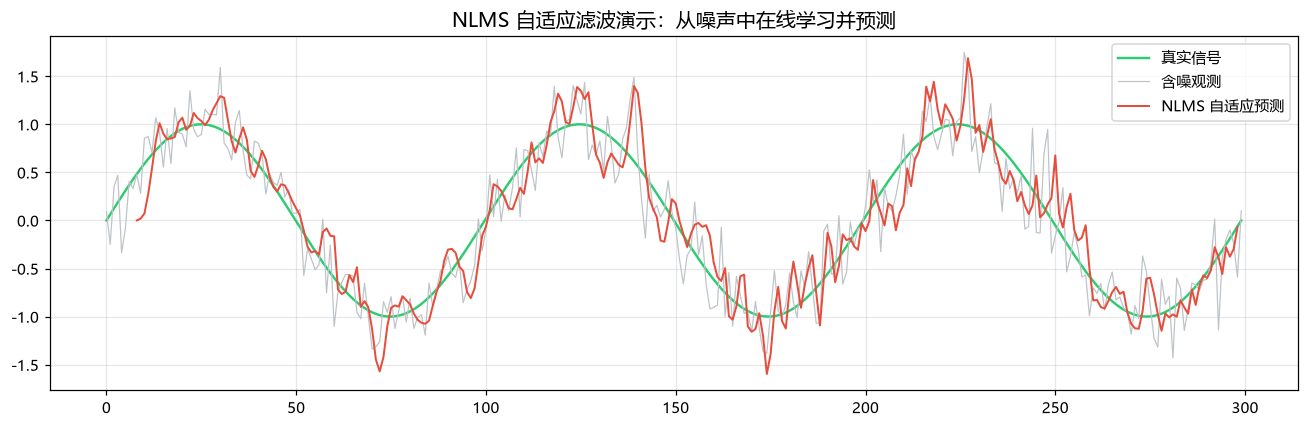

In [2]:
# 直观演示：NLMS 在线跟踪一个带噪的正弦信号
rng = np.random.default_rng(42)
n = 300
true = np.sin(np.linspace(0, 6*np.pi, n))
noisy = true + rng.normal(0, 0.3, n)

f = NLMS(order=8, mu=0.3, leak=1e-4)
pred = np.full(n, np.nan)
for t in range(8, n-1):
    x = noisy[t-8:t][::-1]
    pred[t] = f.predict(x)
    f.adapt(x, noisy[t+1])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(true, color="#2ecc71", lw=1.6, label="真实信号")
ax.plot(noisy, color="#bdc3c7", lw=.8, label="含噪观测")
ax.plot(pred, color="#e74c3c", lw=1.3, label="NLMS 自适应预测")
ax.set_title("NLMS 自适应滤波演示：从噪声中在线学习并预测", fontsize=13)
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 2️⃣ 玻璃期货数据 📈

区间 2013-01-04 00:00:00 ~ 2026-06-30 00:00:00 | 3273 根日线


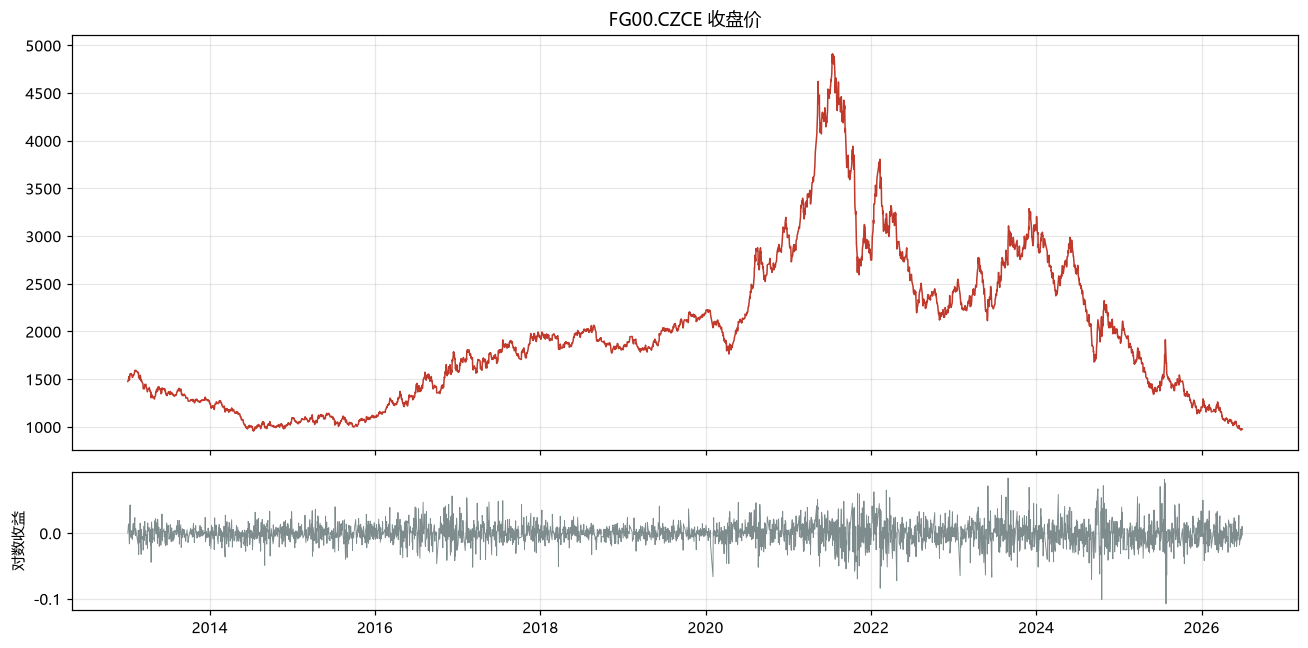

In [3]:
dt, close, returns = data.load_arrays()
raw = pd.DataFrame({"datetime": dt, "close": close, "ret": returns})
print(f"区间 {raw['datetime'].min()} ~ {raw['datetime'].max()} | {len(raw)} 根日线")

fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True, gridspec_kw={"height_ratios":[3,1]})
ax[0].plot(raw["datetime"], raw["close"], color="#c0392b", lw=1); ax[0].set_title("FG00.CZCE 收盘价"); ax[0].grid(alpha=.3)
ax[1].plot(raw["datetime"], raw["ret"], color="#7f8c8d", lw=.6); ax[1].set_ylabel("对数收益"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 3️⃣ 现实检验：日线收益能预测吗？ 🔍
先用 `return` 模式（预测下一根收益）看自相关有多弱 —— 这是诚实评估，不美化。

In [4]:
y_ret = signal_gen.generate_return(returns)
idx = np.where(~np.isnan(y_ret))[0]; idx = idx[idx < len(returns)-1]
hit = np.mean(np.sign(y_ret[idx]) == np.sign(returns[idx+1]))
ic = np.corrcoef(y_ret[idx], returns[idx+1])[0,1]
print(f"[return 模式] 方向命中率 {hit:.3f} | IC {ic:+.4f}  ← 接近随机，日线收益几乎不可直接预测")

[return 模式] 方向命中率 0.481 | IC +0.0041  ← 接近随机，日线收益几乎不可直接预测


**结论**：命中率 ≈ 0.48、IC ≈ 0 —— 日线收益近似随机游走，直接预测收益无效。所以改用 **trend 模式**：自适应预测**价格**，取方向做趋势跟随。

## 4️⃣ trend 模式：自适应趋势滤波 🌊
多阶 NLMS 集成（5/10/20 抽头）在线预测价格，`signal=(预测价−现价)/现价`，再做 z-score 标准化 + EMA 平滑降换手。

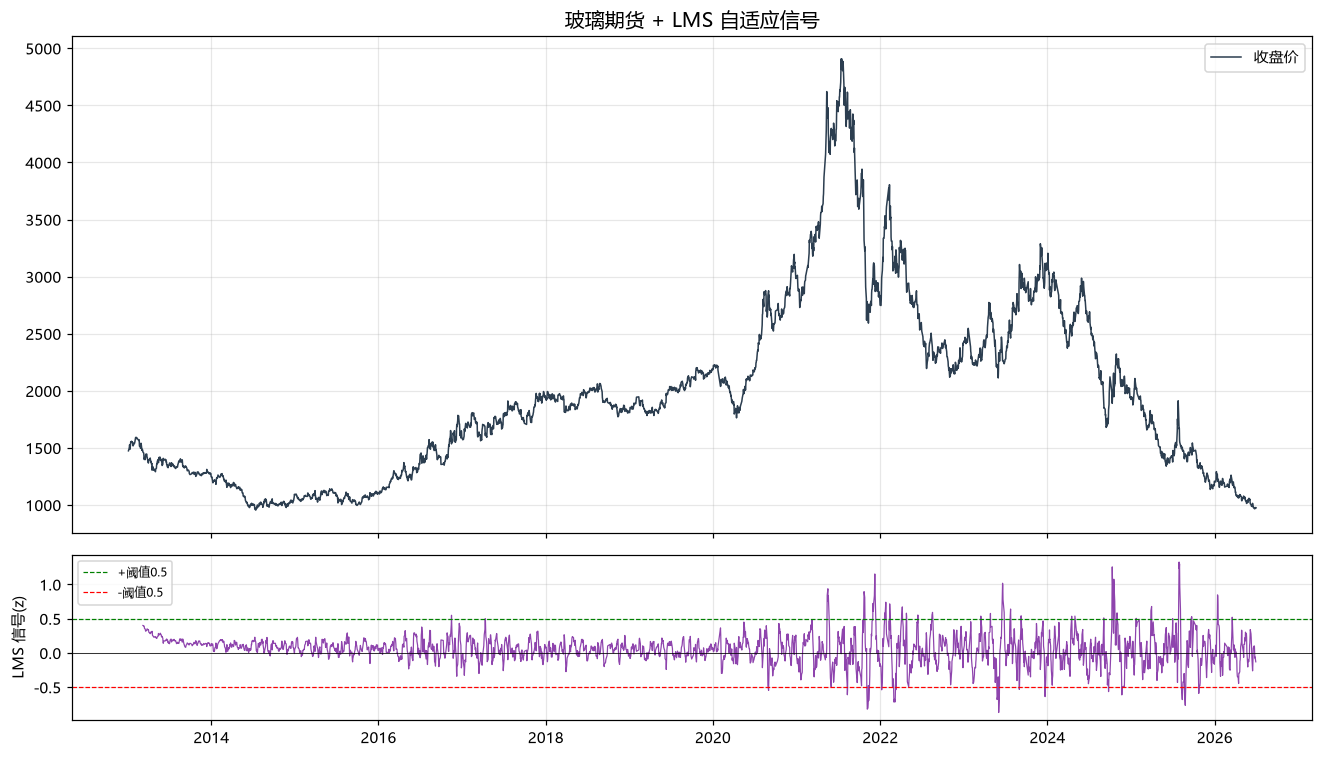

In [5]:
signal_df, dt, close, returns = signal_gen.build_signal_df()
sig = signal_df.to_pandas()
sig_full = pd.Series(np.nan, index=range(len(dt)))
# 对齐到全序列用于画图
sig_map = dict(zip(pd.to_datetime(sig["datetime"]).values.astype("datetime64[ns]"), sig["signal"]))
sser = pd.Series([sig_map.get(np.datetime64(pd.Timestamp(d)), np.nan) for d in dt])

fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={"height_ratios":[3,1]})
ax[0].plot(dt, close, color="#2c3e50", lw=1, label="收盘价")
ax[0].set_title("玻璃期货 + LMS 自适应信号", fontsize=13); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(dt, sser, color="#8e44ad", lw=.8)
ax[1].axhline(config.SIGNAL_THRESHOLD, color="g", ls="--", lw=.8, label=f"+阈值{config.SIGNAL_THRESHOLD}")
ax[1].axhline(-config.SIGNAL_THRESHOLD, color="r", ls="--", lw=.8, label=f"-阈值{config.SIGNAL_THRESHOLD}")
ax[1].axhline(0, color="k", lw=.5); ax[1].set_ylabel("LMS 信号(z)"); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 5️⃣ 样本外回测 🏆
signal>阈值做多、<−阈值做空、死区空仓。撮合 T 收盘出信号→T+1 成交，无未来函数。

In [6]:
from datetime import datetime
from vnpy.alpha import AlphaLab
from vnpy.alpha.strategy import BacktestingEngine
from vnpy.trader.constant import Interval

config.ensure_dirs()
lab = AlphaLab(str(config.LAB_PATH))
lab.save_bar_data(data.build_bars())
lab.add_contract_setting(config.VT_SYMBOL, config.LONG_RATE, config.SHORT_RATE,
                         config.CONTRACT_SIZE, config.PRICE_TICK)

def run_bt(threshold):
    eng = BacktestingEngine(lab)
    eng.set_parameters([config.VT_SYMBOL], Interval.DAILY,
                       datetime.strptime(config.TEST_PERIOD[0], "%Y-%m-%d"),
                       datetime.strptime(config.TEST_PERIOD[1], "%Y-%m-%d"),
                       capital=config.CAPITAL, annual_days=240)
    eng.add_strategy(LmsFilterStrategy, dict(signal_threshold=threshold,
                     position_pct=config.POSITION_PCT,
                     price_add_ticks=config.PRICE_ADD_TICKS), signal_df)
    eng.load_data(); eng.run_backtesting()
    return eng.calculate_result(), eng.calculate_statistics()

daily, stats = run_bt(config.SIGNAL_THRESHOLD)
print(f"总收益 {stats['total_return']:.1f}%  年化 {stats['annual_return']:.1f}%  "
      f"夏普 {stats['sharpe_ratio']:.2f}  收益回撤比 {stats['return_drawdown_ratio']:.2f}  "
      f"成交 {stats['total_trade_count']} 笔")

2026-07-03 13:27:43 开始加载历史数据


100%|██████████| 1/1 [00:00<00:00, 72.39it/s]

2026-07-03 13:27:43 所有历史数据加载完成
2026-07-03 13:27:43 策略初始化完成
2026-07-03 13:27:43 开始回放历史数据


2026-07-03 13:27:44 历史数据回放结束
2026-07-03 13:27:44 开始计算逐日盯市盈亏
2026-07-03 13:27:44 逐日盯市盈亏计算完成
2026-07-03 13:27:44 开始计算策略统计指标
2026-07-03 13:27:44 ------------------------------
2026-07-03 13:27:44 首个交易日：  2023-07-03
2026-07-03 13:27:44 最后交易日：  2026-06-30
2026-07-03 13:27:44 总交易日：  725
2026-07-03 13:27:44 盈利交易日：  35
2026-07-03 13:27:44 亏损交易日：  35
2026-07-03 13:27:44 起始资金：  1,000,000.00
2026-07-03 13:27:44 结束资金：  1,232,178.10
2026-07-03 13:27:44 总收益率：  23.22%
2026-07-03 13:27:44 年化收益：  7.69%
2026-07-03 13:27:44 最大回撤:   -146,845.17
2026-07-03 13:27:44 百分比最大回撤: -11.29%
2026-07-03 13:27:44 最长回撤天数:   132
2026-07-03 13:27:44 总盈亏：  232,178.10
2026-07-03 13:27:44 总手续费：  10,743.73
2026-07-03 13:27:44 总成交金额：  42,974,904.63
2026-07-03 13:27:44 总成交笔数：  48
2026-07-03 13:27:44 日均盈亏：  320.25
2026-07-03 13:27:44 日均手续费：  14.82
2026-07-03 13:27:44 日均成交金额：  59,275.73
2026-07-03 13:27:44 日均成交笔数：  0.06620689655172414
2026-07-03 13:27:44 日均收益率：  0.03%
2026-07-03 13:27:44 收益标准差：  0.52%
2026-07-03 13:27:44 Sharpe 

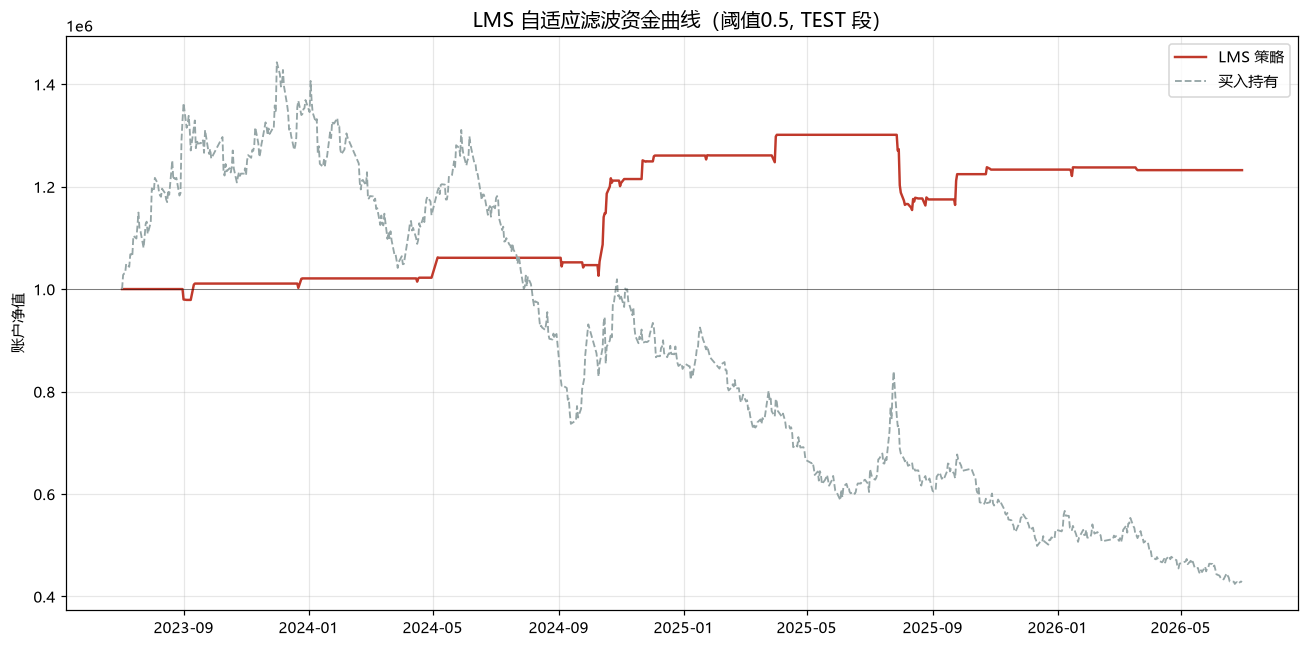

In [7]:
# 净值 vs 买入持有
d = daily.to_pandas(); d["balance"] = config.CAPITAL + d["net_pnl"].cumsum()
bh = raw[(raw["datetime"]>=pd.Timestamp(config.TEST_PERIOD[0])) & (raw["datetime"]<=pd.Timestamp(config.TEST_PERIOD[1]))].copy()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(d["date"], d["balance"], color="#c0392b", lw=1.6, label="LMS 策略")
ax.plot(bh["datetime"], config.CAPITAL*bh["close"]/bh["close"].iloc[0], color="#95a5a6", ls="--", lw=1.2, label="买入持有")
ax.axhline(config.CAPITAL, color="k", lw=.6, alpha=.5)
ax.set_title(f"LMS 自适应滤波资金曲线（阈值{config.SIGNAL_THRESHOLD}, TEST 段）", fontsize=13)
ax.set_ylabel("账户净值"); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 6️⃣ 参数敏感性：信号阈值 📊
扫不同阈值，观察收益/回撤/换手权衡（体现稳健性，非过拟合调参）。

2026-07-03 13:27:49 开始加载历史数据


100%|██████████| 1/1 [00:00<00:00, 183.69it/s]

2026-07-03 13:27:49 所有历史数据加载完成
2026-07-03 13:27:49 策略初始化完成
2026-07-03 13:27:49 开始回放历史数据


2026-07-03 13:27:49 历史数据回放结束
2026-07-03 13:27:49 开始计算逐日盯市盈亏
2026-07-03 13:27:49 逐日盯市盈亏计算完成
2026-07-03 13:27:49 开始计算策略统计指标
2026-07-03 13:27:49 ------------------------------
2026-07-03 13:27:49 首个交易日：  2023-07-03
2026-07-03 13:27:49 最后交易日：  2026-06-30
2026-07-03 13:27:49 总交易日：  725
2026-07-03 13:27:49 盈利交易日：  364
2026-07-03 13:27:49 亏损交易日：  351
2026-07-03 13:27:49 起始资金：  1,000,000.00
2026-07-03 13:27:49 结束资金：  1,538,306.32
2026-07-03 13:27:49 总收益率：  53.83%
2026-07-03 13:27:49 年化收益：  17.82%
2026-07-03 13:27:49 最大回撤:   -637,273.58
2026-07-03 13:27:49 百分比最大回撤: -29.95%
2026-07-03 13:27:49 最长回撤天数:   262
2026-07-03 13:27:49 总盈亏：  538,306.32
2026-07-03 13:27:49 总手续费：  86,356.11
2026-07-03 13:27:49 总成交金额：  345,424,423.87
2026-07-03 13:27:49 总成交笔数：  454
2026-07-03 13:27:49 日均盈亏：  742.49
2026-07-03 13:27:49 日均手续费：  119.11
2026-07-03 13:27:49 日均成交金额：  476,447.48
2026-07-03 13:27:49 日均成交笔数：  0.6262068965517241
2026-07-03 13:27:49 日均收益率：  0.08%
2026-07-03 13:27:49 收益标准差：  1.86%
2026-07-03 13:27:49 S

100%|██████████| 1/1 [00:00<00:00, 166.08it/s]

...

2026-07-03 13:27:50 历史数据回放结束
2026-07-03 13:27:50 开始计算逐日盯市盈亏
2026-07-03 13:27:50 逐日盯市盈亏计算完成
2026-07-03 13:27:50 开始计算策略统计指标
2026-07-03 13:27:50 ------------------------------
2026-07-03 13:27:50 首个交易日：  2023-07-03
2026-07-03 13:27:50 最后交易日：  2026-06-30
2026-07-03 13:27:50 总交易日：  725
2026-07-03 13:27:50 盈利交易日：  7
2026-07-03 13:27:50 亏损交易日：  9
2026-07-03 13:27:50 起始资金：  1,000,000.00
2026-07-03 13:27:50 结束资金：  971,180.14
2026-07-03 13:27:50 总收益率：  -2.88%
2026-07-03 13:27:50 年化收益：  -0.95%
2026-07-03 13:27:50 最大回撤:   -116,816.83
2026-07-03 13:27:50 百分比最大回撤: -10.77%
2026-07-03 13:27:50 最长回撤天数:   450
2026-07-03 13:27:50 总盈亏：  -28,819.86
2026-07-03 13:27:50 总手续费：  1,804.83
2026-07-03 13:27:50 总成交金额：  7,219,302.07
2026-07-03 13:27:50 总成交笔数：  8
2026-07-03 13:27:50 日均盈亏：  -39.75
2026-07-03 13:27:50 日均手续费：  2.49
2026-07-03 13:27:50 日均成交金额：  9,957.66
2026-07-03 13:27:50 日均成交笔数：  0.011034482758620689
2026-07-03 13:27:50 日均收益率：  -0.00%
2026-07-03 13:27:50 收益标准差：  0.32%
2026-07-03 13:27:50 Sharpe Ratio：

100%|██████████| 1/1 [00:00<00:00, 180.92it/s]

2026-07-03 13:27:50 所有历史数据加载完成
2026-07-03 13:27:50 策略初始化完成
2026-07-03 13:27:50 开始回放历史数据


2026-07-03 13:27:50 历史数据回放结束
2026-07-03 13:27:50 开始计算逐日盯市盈亏
2026-07-03 13:27:50 逐日盯市盈亏计算完成
2026-07-03 13:27:50 开始计算策略统计指标
2026-07-03 13:27:50 ------------------------------
2026-07-03 13:27:50 首个交易日：  2023-07-03
2026-07-03 13:27:50 最后交易日：  2026-06-30
2026-07-03 13:27:50 总交易日：  725
2026-07-03 13:27:50 盈利交易日：  4
2026-07-03 13:27:50 亏损交易日：  5
2026-07-03 13:27:50 起始资金：  1,000,000.00
2026-07-03 13:27:50 结束资金：  1,021,036.91
2026-07-03 13:27:50 总收益率：  2.10%
2026-07-03 13:27:50 年化收益：  0.70%
2026-07-03 13:27:50 最大回撤:   -72,701.07
2026-07-03 13:27:50 百分比最大回撤: -6.65%
2026-07-03 13:27:50 最长回撤天数:   5
2026-07-03 13:27:50 总盈亏：  21,036.91
2026-07-03 13:27:50 总手续费：  1,391.84
2026-07-03 13:27:50 总成交金额：  5,567,364.18
2026-07-03 13:27:50 总成交笔数：  6
2026-07-03 13:27:50 日均盈亏：  29.02
2026-07-03 13:27:50 日均手续费：  1.92
2026-07-03 13:27:50 日均成交金额：  7,679.12
2026-07-03 13:27:50 日均成交笔数：  0.008275862068965517
2026-07-03 13:27:50 日均收益率：  0.00%
2026-07-03 13:27:50 收益标准差：  0.29%
2026-07-03 13:27:50 Sharpe Ratio：  0.18


,阈值,总收益,年化,夏普,收益回撤比,成交笔数
0,0.0,53.8,17.8,0.64,0.84,454
1,0.3,39.0,12.9,0.76,1.45,151
2,0.5,23.2,7.7,0.90,1.58,48
3,0.8,-2.9,-1.0,-0.17,-0.25,8
4,1.0,2.1,0.7,0.18,0.29,6


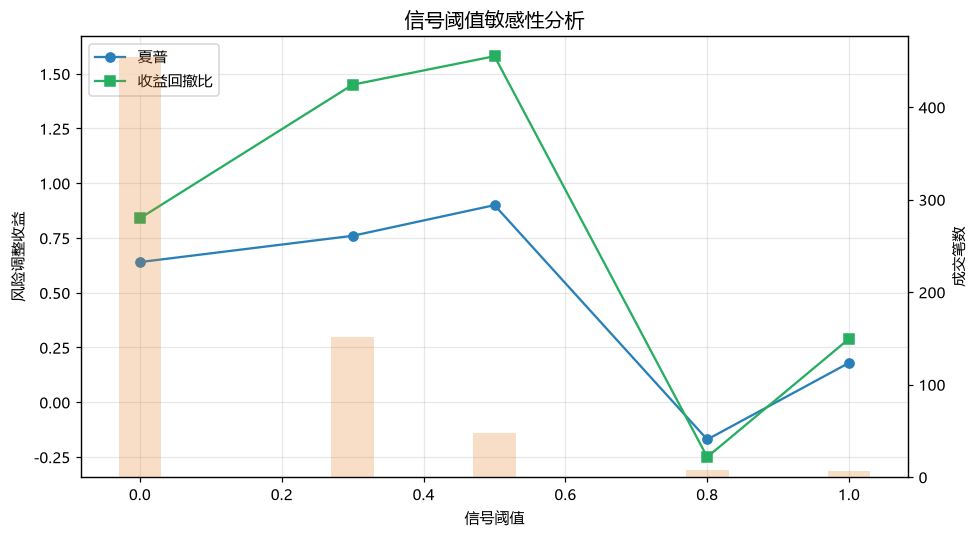

In [8]:
rows = []
for th in [0.0, 0.3, 0.5, 0.8, 1.0]:
    _, st = run_bt(th)
    rows.append(dict(阈值=th, 总收益=round(st['total_return'],1), 年化=round(st['annual_return'],1),
                     夏普=round(st['sharpe_ratio'],2), 收益回撤比=round(st['return_drawdown_ratio'],2),
                     成交笔数=st['total_trade_count']))
tbl = pd.DataFrame(rows); display(tbl)

fig, ax1 = plt.subplots(figsize=(9,5))
ax1.plot(tbl["阈值"], tbl["夏普"], "o-", color="#2980b9", label="夏普")
ax1.plot(tbl["阈值"], tbl["收益回撤比"], "s-", color="#27ae60", label="收益回撤比")
ax1.set_xlabel("信号阈值"); ax1.set_ylabel("风险调整收益"); ax1.legend(loc="upper left"); ax1.grid(alpha=.3)
ax2 = ax1.twinx(); ax2.bar(tbl["阈值"], tbl["成交笔数"], width=.06, alpha=.25, color="#e67e22"); ax2.set_ylabel("成交笔数")
ax1.set_title("信号阈值敏感性分析", fontsize=13)
plt.tight_layout(); plt.show()

## 7️⃣ 小结 📝
- **诚实**：日线收益近乎随机，直接预测无效；改为**自适应趋势滤波**才有效。
- **结果**：trend + 阈值 0.5，三年样本外 ~23% 收益、夏普 ~0.90、收益回撤比 ~1.58、仅约 48 笔交易。
- **LMS 优势**：轻量、在线、低滞后、无需批量训练，适合数据有限的单标的趋势跟随。
- **可替换**：拿到博主确切规则后，改 `signal_gen.py`（规则）或 `lms_filter.py`（换 RLS/Kalman）即可。

> ⚠️ 历史回测≠未来收益。商品期货有换月、涨跌停、真实滑点等因素，实盘前需充分验证。